In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_parquet("sample_0.01.parquet")

In [3]:
df.head(10)

,instance_id,cluster_size,user_id,database_id,query_id,arrival_timestamp,compile_duration_ms,queue_duration_ms,execution_duration_ms,feature_fingerprint,...,num_permanent_tables_accessed,num_external_tables_accessed,num_system_tables_accessed,read_table_ids,write_table_ids,mbytes_scanned,mbytes_spilled,num_joins,num_scans,num_aggregations
0,0,NaN,1,0,4551824,2024-03-27 22:25:55.623956,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
1,0,NaN,2,0,6118838,2024-03-27 20:13:36.392615,8.0,0,16,fbf9221a42c71200bd9109031fa72bf1fd8329cd4d2af5...,...,0.0,0.0,0.0,310730,NaN,4.0,0.0,0,1,2
2,0,NaN,2,0,5465193,2024-03-14 23:02:24.025019,601.0,0,603,dababeaabbdeb9014775485d77320127cd3585370b3eb4...,...,1.0,0.0,0.0,156,299,221.0,0.0,0,1,2
3,0,NaN,1,0,5187207,2024-03-15 01:47:17.987274,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
4,0,NaN,2,0,1775833,2024-03-28 00:11:13.849736,147.0,0,197,1b97ecc98a74040abf33e65b0d82583309100405d3905d...,...,0.0,0.0,0.0,NaN,82552,0.0,0.0,0,0,2
5,0,NaN,0,0,3164729,2024-04-05 20:21:09.779871,8318.0,0,9063,ba449083e30ca0bb28d7c7662352ba91d5e1d19bc778cf...,...,0.0,1.0,0.0,NaN,NaN,0.0,0.0,0,0,2
6,0,NaN,1,0,5502803,2024-03-14 21:40:33.894606,21.0,0,27,76f95b324e8b84651f4efd79e43aab93b64a40e1bd9e59...,...,1.0,0.0,0.0,1602,NaN,6.0,0.0,0,1,2
7,0,NaN,1,0,1981970,2024-04-14 20:47:31.499177,7.0,0,9,44098316b35fc2f551c2071b0dc3e937af789dda573a15...,...,1.0,0.0,0.0,13003,NaN,64.0,0.0,0,1,2
8,0,NaN,1,0,5428811,2024-03-15 01:38:26.273415,10.0,0,12,b44a6d6cd2cfc9ee7c3c567007e8d0e6d466b571ca8a1b...,...,1.0,0.0,0.0,355,NaN,96.0,0.0,0,1,2
9,0,NaN,2,0,5516969,2024-03-15 03:20:56.507642,6855.0,0,6858,NaN,...,2.0,0.0,0.0,"26,72",281027,17020.0,0.0,1,2,2


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4331078 entries, 0 to 4331077
Data columns (total 24 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   instance_id                    int32         
 1   cluster_size                   float64       
 2   user_id                        int64         
 3   database_id                    int64         
 4   query_id                       int64         
 5   arrival_timestamp              datetime64[us]
 6   compile_duration_ms            float64       
 7   queue_duration_ms              int64         
 8   execution_duration_ms          int64         
 9   feature_fingerprint            str           
 10  was_aborted                    int32         
 11  was_cached                     int32         
 12  cache_source_query_id          float64       
 13  query_type                     str           
 14  num_permanent_tables_accessed  float64       
 15  num_external_tables_access

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
instance_id,4331078.0,82.756888,0.0,34.0,96.0,109.0,199.0,51.517825
cluster_size,3670927.0,5.666659,1.0,2.0,3.0,6.0,80.0,7.198708
user_id,4331078.0,469.471203,0.0,0.0,0.0,1.0,81450.0,4516.449796
database_id,4331078.0,0.729946,0.0,0.0,0.0,0.0,138.0,3.967029
query_id,4331078.0,9255186.645655,0.0,1636820.25,4771069.0,11176826.5,58700811.0,11946220.519257
arrival_timestamp,4331078,2024-04-16 04:18:27.921852,2024-03-01 00:00:05.086395,2024-03-24 16:44:57.207831,2024-04-17 00:49:48.623788,2024-05-08 04:50:24.641537,2024-05-30 23:59:42.680457,NaN
compile_duration_ms,3843599.0,2676.905426,0.0,7.0,41.0,298.0,35439010.0,63825.673074
queue_duration_ms,4331078.0,890.265798,0.0,0.0,0.0,0.0,10900669.0,27768.869592
execution_duration_ms,4331078.0,2786.267071,0.0,8.0,46.0,309.0,103865692.0,85125.128804
was_aborted,4331078.0,0.005029,0.0,0.0,0.0,0.0,1.0,0.070739


In [6]:
df.nunique()

instance_id                          171
cluster_size                          27
user_id                            38425
database_id                           73
query_id                         3761086
arrival_timestamp                4331074
compile_duration_ms                63527
queue_duration_ms                  40186
execution_duration_ms              68892
feature_fingerprint              1193984
was_aborted                            2
was_cached                             2
cache_source_query_id             174702
query_type                            10
num_permanent_tables_accessed        621
num_external_tables_accessed         247
num_system_tables_accessed            54
read_table_ids                    957660
write_table_ids                   535410
mbytes_scanned                     68127
mbytes_spilled                     18092
num_joins                            170
num_scans                            196
num_aggregations                     248
dtype: int64

In [7]:
df.isnull().sum()

instance_id                            0
cluster_size                      660151
user_id                                0
database_id                            0
query_id                               0
arrival_timestamp                      0
compile_duration_ms               487479
queue_duration_ms                      0
execution_duration_ms                  0
feature_fingerprint               525907
was_aborted                            0
was_cached                             0
cache_source_query_id            3870375
query_type                             0
num_permanent_tables_accessed     465915
num_external_tables_accessed      465915
num_system_tables_accessed        465915
read_table_ids                   1444155
write_table_ids                  1869839
mbytes_scanned                    504046
mbytes_spilled                    504046
num_joins                              0
num_scans                              0
num_aggregations                       0
dtype: int64

In [8]:
cpdf = df.copy()

In [ ]:
cpdf = cpdf.sort_values(by=['instance_id', 'arrival_timestamp'])

cpdf['cluster_size_clean'] = cpdf.groupby('instance_id')['cluster_size'].ffill()

cpdf['cluster_size_clean'] = cpdf.groupby('instance_id')['cluster_size_clean'].bfill()

global_median = cpdf['cluster_size'].median()
cpdf['cluster_size_clean'] = cpdf['cluster_size_clean'].fillna(global_median)

print(f"Values missing BEFORE: {cpdf['cluster_size'].isnull().sum()}")
print(f"Values missing AFTER:  {cpdf['cluster_size_clean'].isnull().sum()}")


Values missing BEFORE: 660151
Values missing AFTER:  0


In [ ]:
print("--- Hypothesis Check: Does Cache skip Compilation? ---")
cache_check = cpdf.groupby('was_cached')['compile_duration_ms'].apply(lambda x: x.isnull().mean() * 100)
print(f"Percentage of Missing Compile Times:\n{cache_check}")
print("\n--- Hypothesis Check: Aborted Queries ---")
abort_check = cpdf.groupby('was_aborted')['compile_duration_ms'].apply(lambda x: x.isnull().mean() * 100)
print(f"Percentage of Missing Compile Times by Abort Status:\n{abort_check}")

missing_compile = cpdf['compile_duration_ms'].isnull()
cached = cpdf['was_cached'] == 1
explained_by_cache = (missing_compile & cached).sum()
total_missing = missing_compile.sum()

print(f"\nTotal Missing Compile Times: {total_missing}")
print(f"Explained by Caching: {explained_by_cache} ({explained_by_cache/total_missing:.1%})")

--- Hypothesis Check: Does Cache skip Compilation? ---
Percentage of Missing Compile Times:
was_cached
0      0.691819
1    100.000000
Name: compile_duration_ms, dtype: float64

--- Hypothesis Check: Aborted Queries ---
Percentage of Missing Compile Times by Abort Status:
was_aborted
0    10.965782
1    68.547424
Name: compile_duration_ms, dtype: float64

Total Missing Compile Times: 487479
Explained by Caching: 460703 (94.5%)


In [ ]:
cpdf['compile_duration_ms'] = cpdf['compile_duration_ms'].fillna(0)

cpdf['mbytes_scanned'] = cpdf['mbytes_scanned'].fillna(0)
cpdf['mbytes_spilled'] = cpdf['mbytes_spilled'].fillna(0)

HOURLY_RATE_PER_NODE = 2.00
cpdf['estimated_cost_usd'] = (
    (cpdf['execution_duration_ms'] / (1000 * 60 * 60)) * 
    cpdf['cluster_size_clean'] *
    HOURLY_RATE_PER_NODE
)

cpdf['scan_efficiency_mb_per_sec'] = (
    cpdf['mbytes_scanned'] /
    ((cpdf['execution_duration_ms'] / 1000) + 1)
)

cpdf['hour_of_day'] = cpdf['arrival_timestamp'].dt.hour
cpdf['day_of_week'] = cpdf['arrival_timestamp'].dt.day_name()

cpdf['complexity_score'] = (
    (cpdf['num_joins'] * 3) +
    (cpdf['num_aggregations'] * 2) +
    (cpdf['num_scans'] * 1)
)

# CHECK THE RESULTS
print("--- Feature Engineering Check ---")
print(cpdf[['estimated_cost_usd', 'scan_efficiency_mb_per_sec', 'complexity_score']].describe().round(4))

--- Feature Engineering Check ---
       estimated_cost_usd  scan_efficiency_mb_per_sec  complexity_score
count        4.331078e+06                4.331078e+06      4.331078e+06
mean         1.560000e-02                4.399365e+02      6.720900e+00
std          5.733000e-01                3.808861e+03      2.603870e+01
min          0.000000e+00                0.000000e+00      0.000000e+00
25%          0.000000e+00                0.000000e+00      4.000000e+00
50%          1.000000e-04                2.215190e+01      5.000000e+00
75%          8.000000e-04                1.476834e+02      6.000000e+00
max          2.971351e+02                2.845578e+06      2.055100e+04


In [ ]:
has_read = cpdf['read_table_ids'].notnull()
has_write = cpdf['write_table_ids'].notnull()

conditions = [
    (has_read & has_write),  
    (has_read & ~has_write), 
    (~has_read & has_write), 
    (~has_read & ~has_write) 
]

choices = ['Read/Write', 'Read Only', 'Write Only', 'System/Metadata']

# Create the column using efficient numpy select
cpdf['workload_type'] = np.select(conditions, choices, default='Unknown')

table_cols = [
    'num_permanent_tables_accessed',
    'num_external_tables_accessed',
    'num_system_tables_accessed'
]
cpdf[table_cols] = cpdf[table_cols].fillna(0)

cpdf['total_tables_accessed'] = (
    cpdf['num_permanent_tables_accessed'] +
    cpdf['num_external_tables_accessed'] +
    cpdf['num_system_tables_accessed']
)

scope_conditions = [
    (cpdf['num_external_tables_accessed'] > 0), 
    (cpdf['num_system_tables_accessed'] > 0),   
    (cpdf['num_permanent_tables_accessed'] > 0) 
]
scope_choices = ['External (Data Lake)', 'System Internal', 'Core Warehousing']

cpdf['access_scope'] = np.select(scope_conditions, scope_choices, default='Metadata Only')

print("--- Workload Type Distribution ---")
print(cpdf['workload_type'].value_counts())

print("\n--- Access Scope Distribution ---")
print(cpdf['access_scope'].value_counts())

print("\n--- Check on Missing Table Counts (Should be 0) ---")
print(cpdf[table_cols].isnull().sum())

--- Workload Type Distribution ---
workload_type
Read/Write         1739381
Read Only          1147542
System/Metadata     722297
Write Only          721858
Name: count, dtype: int64

--- Access Scope Distribution ---
access_scope
Core Warehousing        3053956
Metadata Only           1129674
System Internal          103389
External (Data Lake)      44059
Name: count, dtype: int64

--- Check on Missing Table Counts (Should be 0) ---
num_permanent_tables_accessed    0
num_external_tables_accessed     0
num_system_tables_accessed       0
dtype: int64


In [ ]:
cpdf['feature_fingerprint'] = cpdf['feature_fingerprint'].fillna('UNKNOWN_FINGERPRINT')

fingerprint_counts = cpdf['feature_fingerprint'].value_counts()

cpdf['fingerprint_frequency'] = cpdf['feature_fingerprint'].map(fingerprint_counts)

traffic_conditions = [
    (cpdf['fingerprint_frequency'] >= 100),  
    (cpdf['fingerprint_frequency'] > 5),     
    (cpdf['fingerprint_frequency'] <= 5)     
]
traffic_choices = ['Automated / App', 'Recurring Report', 'Ad-hoc / Human']

cpdf['traffic_source'] = np.select(traffic_conditions, traffic_choices, default='Unknown')

cpdf['fingerprint_std_dev_ms'] = cpdf.groupby('feature_fingerprint')['execution_duration_ms'].transform('std')

cpdf['fingerprint_std_dev_ms'] = cpdf['fingerprint_std_dev_ms'].fillna(0)

print("--- Traffic Source Distribution ---")
print(cpdf['traffic_source'].value_counts())



--- Traffic Source Distribution ---
traffic_source
Automated / App     2447237
Ad-hoc / Human      1386918
Recurring Report     496923
Name: count, dtype: int64


In [ ]:
cols_to_drop = [
    'cluster_size',
    'read_table_ids',
    'write_table_ids',
    'execution_duration_safe',
    'cache_source_query_id'
]
cpdf.drop(columns=[c for c in cols_to_drop if c in cpdf.columns], inplace=True)

cat_cols = [
    'query_type', 'workload_type', 'access_scope',
    'traffic_source', 'day_of_week', 'user_id', 'database_id'
]
for col in cat_cols:
    if col in cpdf.columns:
        cpdf[col] = cpdf[col].astype('category')

float_cols = cpdf.select_dtypes(include=['float64']).columns
cpdf[float_cols] = cpdf[float_cols].astype('float32')

int_cols = cpdf.select_dtypes(include=['int64']).columns
for col in int_cols:
    if col != 'arrival_timestamp':
        cpdf[col] = pd.to_numeric(cpdf[col], downcast='integer')

print("--- Optimization Complete ---")
print(cpdf.info())

--- Optimization Complete ---
<class 'pandas.DataFrame'>
Index: 4331078 entries, 10679 to 1961206
Data columns (total 32 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   instance_id                    int32         
 1   user_id                        category      
 2   database_id                    category      
 3   query_id                       int32         
 4   arrival_timestamp              datetime64[us]
 5   compile_duration_ms            float32       
 6   queue_duration_ms              int32         
 7   execution_duration_ms          int32         
 8   feature_fingerprint            str           
 9   was_aborted                    int32         
 10  was_cached                     int32         
 11  query_type                     category      
 12  num_permanent_tables_accessed  float32       
 13  num_external_tables_accessed   float32       
 14  num_system_tables_accessed     float32       
 1

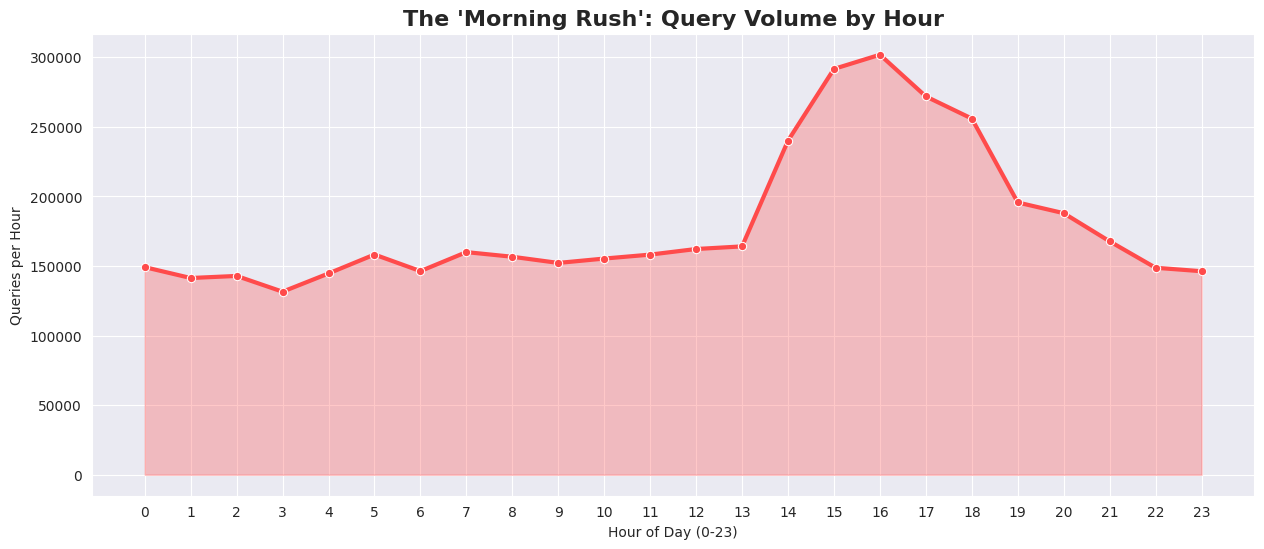

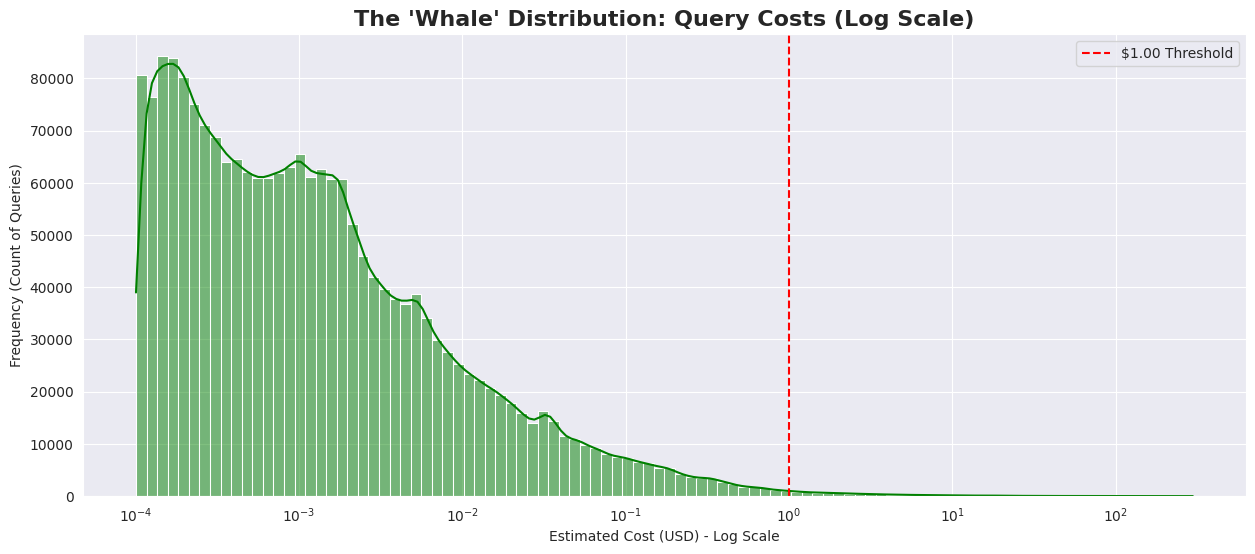

/tmp/ipykernel_928/3565135320.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='workload_type', y='execution_duration_ms', data=viz_data, palette='viridis')


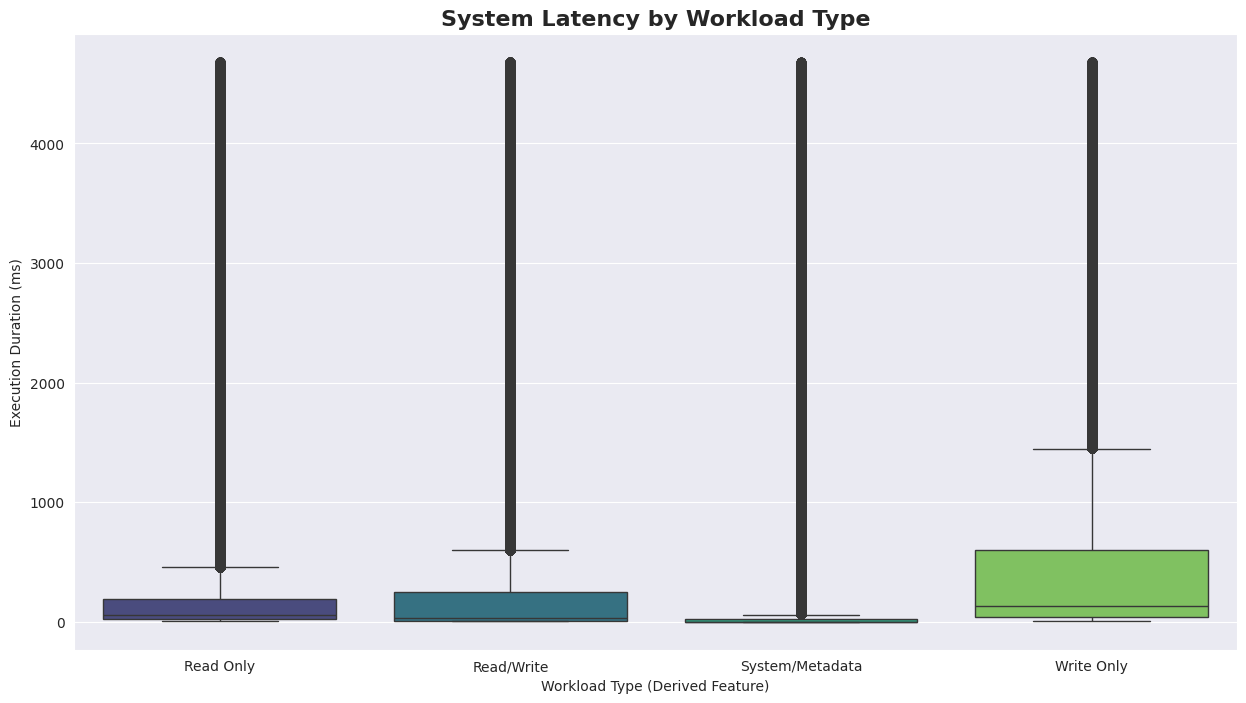

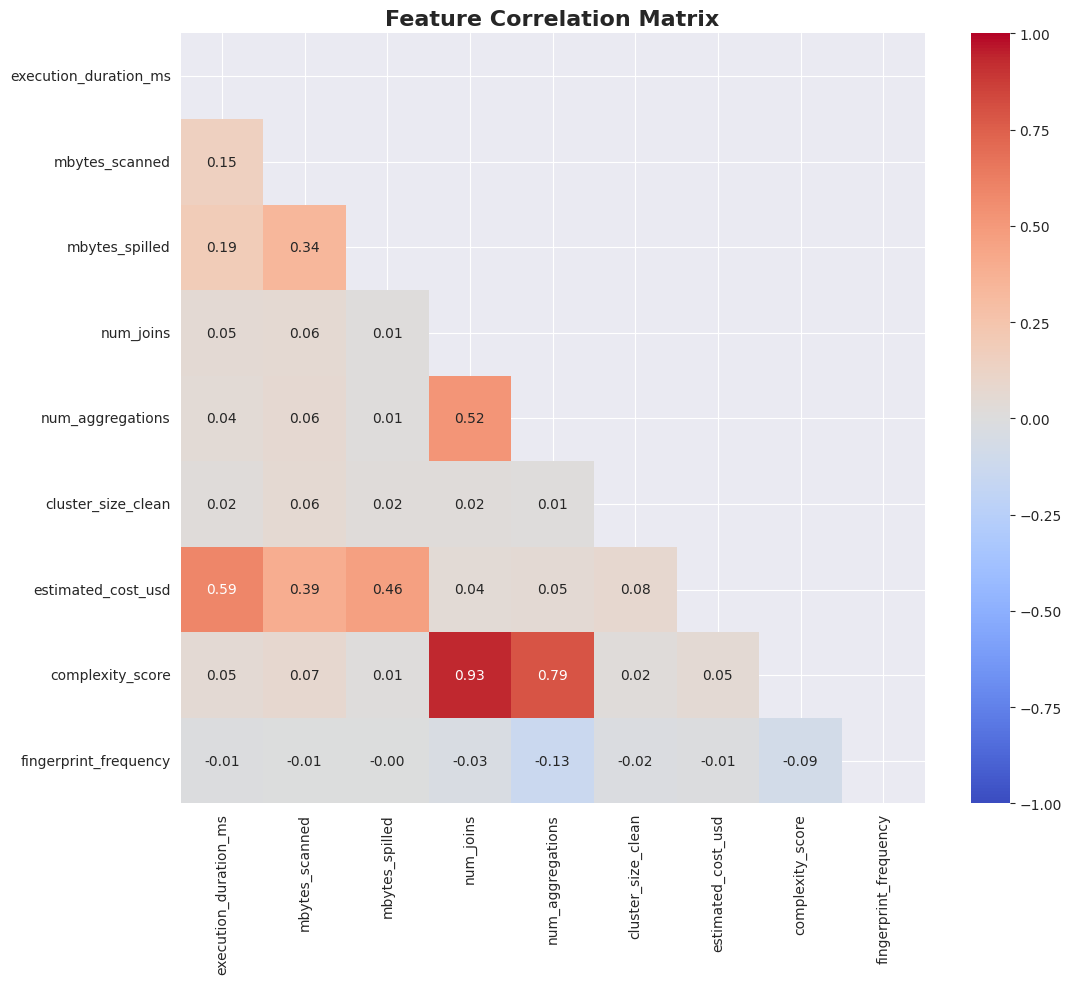

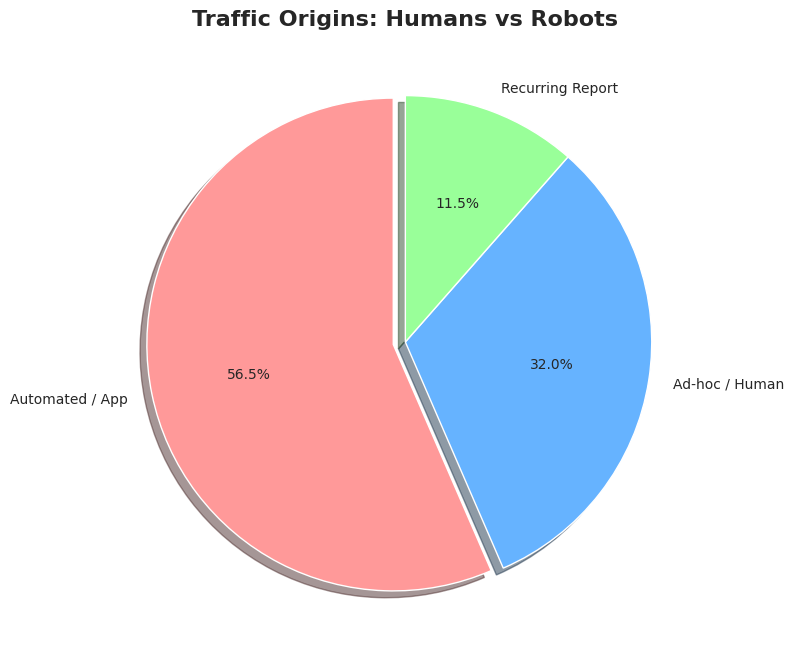

In [ ]:

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (15, 8)

plt.figure(figsize=(15, 6))
hourly_counts = cpdf.groupby('hour_of_day')['query_id'].count()
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values, linewidth=3, marker='o', color='#FF4B4B')

plt.title("The 'Morning Rush': Query Volume by Hour", fontsize=16, fontweight='bold')
plt.ylabel("Queries per Hour")
plt.xlabel("Hour of Day (0-23)")
plt.xticks(range(0, 24))
plt.fill_between(hourly_counts.index, hourly_counts.values, alpha=0.3, color='#FF4B4B')

plt.savefig('eda_morning_rush.png')
plt.show()  

plt.figure(figsize=(15, 6))
cost_data = cpdf[cpdf['estimated_cost_usd'] > 0.0001]

sns.histplot(cost_data['estimated_cost_usd'], bins=100, log_scale=True, color='green', kde=True)

plt.title("The 'Whale' Distribution: Query Costs (Log Scale)", fontsize=16, fontweight='bold')
plt.xlabel("Estimated Cost (USD) - Log Scale")
plt.ylabel("Frequency (Count of Queries)")
plt.axvline(x=1.0, color='red', linestyle='--', label='$1.00 Threshold')
plt.legend()

plt.savefig('eda_cost_dist.png')
plt.show()

plt.figure(figsize=(15, 8))
# Filter extreme outliers (95th percentile) just for the plot readability
duration_cutoff = cpdf['execution_duration_ms'].quantile(0.95)
viz_data = cpdf[cpdf['execution_duration_ms'] < duration_cutoff]

sns.boxplot(x='workload_type', y='execution_duration_ms', data=viz_data, palette='viridis')

plt.title("System Latency by Workload Type", fontsize=16, fontweight='bold')
plt.xlabel("Workload Type (Derived Feature)")
plt.ylabel("Execution Duration (ms)")

plt.savefig('eda_workload_perf.png')
plt.show()

plt.figure(figsize=(12, 10))

numeric_cols = [
    'execution_duration_ms', 'mbytes_scanned', 'mbytes_spilled',
    'num_joins', 'num_aggregations', 'cluster_size_clean',
    'estimated_cost_usd', 'complexity_score', 'fingerprint_frequency'
]
corr_matrix = cpdf[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix", fontsize=16, fontweight='bold')

plt.savefig('eda_correlation.png')
plt.show()

plt.figure(figsize=(10, 8))
source_counts = cpdf['traffic_source'].value_counts()
colors = ['#ff9999','#66b3ff','#99ff99']

plt.pie(source_counts, labels=source_counts.index, autopct='%1.1f%%', colors=colors,
        startangle=90, explode=(0.05, 0, 0), shadow=True)

plt.title("Traffic Origins: Humans vs Robots", fontsize=16, fontweight='bold')

plt.savefig('eda_traffic_source.png')
plt.show()

In [16]:
cpdf.isnull().sum()

instance_id                      0
user_id                          0
database_id                      0
query_id                         0
arrival_timestamp                0
compile_duration_ms              0
queue_duration_ms                0
execution_duration_ms            0
feature_fingerprint              0
was_aborted                      0
was_cached                       0
query_type                       0
num_permanent_tables_accessed    0
num_external_tables_accessed     0
num_system_tables_accessed       0
mbytes_scanned                   0
mbytes_spilled                   0
num_joins                        0
num_scans                        0
num_aggregations                 0
cluster_size_clean               0
estimated_cost_usd               0
scan_efficiency_mb_per_sec       0
hour_of_day                      0
day_of_week                      0
complexity_score                 0
workload_type                    0
total_tables_accessed            0
access_scope        